# Hate Speech Detection on Tweets using RNN, LSTM, and Word2Vec Embeddings
## Herald College, Kathmandu — 6CS012 Final Portfolio Project
**Task:** Binary Text Classification — Racist/Sexist Tweet Detection  
**Dataset:** Racist-Sexist Tweet Dataset (31,962 training samples)  
**Models:** Simple RNN | LSTM (Trainable Embedding) | LSTM (Pretrained GloVe/Word2Vec)

## 1. Environment Setup & Library Imports

In [1]:
# Cell 1: Install dependencies
!pip install -q gensim contractions gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 7.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.9 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings('ignore')
print("Warning suppression active.")

Warning suppression active.


In [3]:
# Cell 2: All Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time

# NLP
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import contractions

# Wordcloud
from wordcloud import WordCloud
from collections import Counter

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report
)

# Keras / TF
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM,
    Dense, Dropout, Bidirectional
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Gensim Word2Vec
import gensim.downloader as gensim_api

print(f"TF version: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
2026-05-06 14:31:19.363861: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778077879.540104      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778077879.593833      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778077880.011009      57 computation_placer.cc:177] computation placer already registered. Please check linkage a

TF version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


# **All Imports**

In [24]:
# Cell 3: Load Dataset
train_df = pd.read_csv("/kaggle/input/datasets/nabinpyakurel/racist-sexist-tweet-dataset/7. Racist Sexist or Not Dataset/train_racisit.csv")
test_df  = pd.read_csv("/kaggle/input/datasets/nabinpyakurel/racist-sexist-tweet-dataset/7. Racist Sexist or Not Dataset/test_racisit.csv")  # ← adjust filename if different

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

print("\nTrain Columns:", train_df.columns.tolist())
print("Test Columns :", test_df.columns.tolist())

print("\nTrain first rows:")
display(train_df.head())

print("\nTest first rows:")
display(test_df.head())

# Check label column — adjust 'label' if your column is named differently
print("\nTrain label distribution:")
print(train_df['label'].value_counts())


Train Shape: (31962, 3)
Test Shape : (17197, 2)

Train Columns: ['id', 'label', 'tweet']
Test Columns : ['id', 'tweet']

Train first rows:


,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation



Test first rows:


,id,tweet
0,31963,#studiolife #aislife #requires #passion #dedic...
1,31964,@user #white #supremacists want everyone to s...
2,31965,safe ways to heal your #acne!! #altwaystohe...
3,31966,is the hp and the cursed child book up for res...
4,31967,"3rd #bihday to my amazing, hilarious #nephew..."



Train label distribution:
label
0    29720
1     2242
Name: count, dtype: int64


In [23]:
print(test_df.columns.tolist())
print(test_df.head())

['id', 'tweet']
      id                                              tweet
0  31963  #studiolife #aislife #requires #passion #dedic...
1  31964   @user #white #supremacists want everyone to s...
2  31965  safe ways to heal your #acne!!    #altwaystohe...
3  31966  is the hp and the cursed child book up for res...
4  31967    3rd #bihday to my amazing, hilarious #nephew...


## 2. Data Loading & Exploration

Label distribution:
label
0    29720
1     2242
Name: count, dtype: int64

Class balance:
label
0    93.0
1     7.0
Name: proportion, dtype: float64%


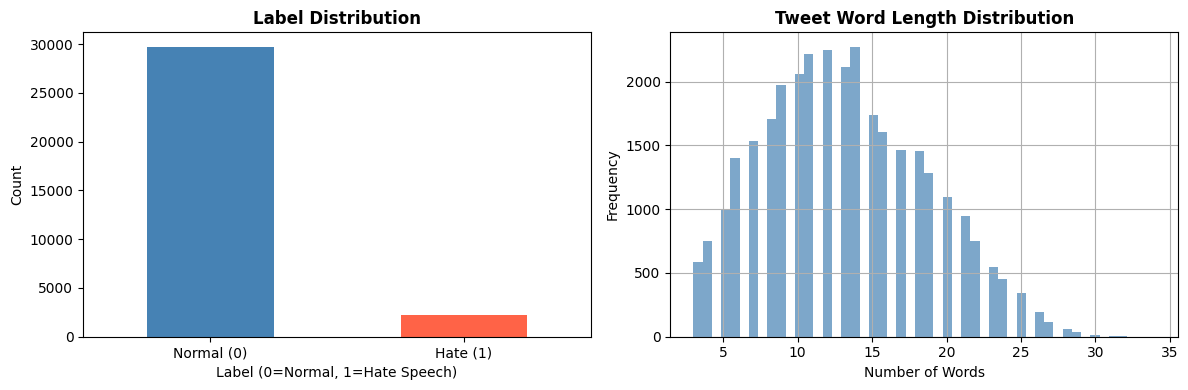


Tweet length stats:
count    31962.00000
mean        13.15872
std          5.47815
min          3.00000
25%          9.00000
50%         13.00000
75%         17.00000
max         34.00000
Name: tweet_len, dtype: float64


In [8]:
# Cell 4: Exploratory Data Analysis
print("Label distribution:")
print(df['label'].value_counts())
print(f"\nClass balance:\n{df['label'].value_counts(normalize=True).round(3) * 100}%")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['label'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','tomato'])
axes[0].set_title('Label Distribution', fontweight='bold')
axes[0].set_xlabel('Label (0=Normal, 1=Hate Speech)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Normal (0)', 'Hate (1)'], rotation=0)

# Tweet length distribution
df['tweet_len'] = df['tweet'].apply(lambda x: len(str(x).split()))
df['tweet_len'].hist(bins=50, ax=axes[1], color='steelblue', alpha=0.7)
axes[1].set_title('Tweet Word Length Distribution', fontweight='bold')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig("eda.png", dpi=150)
plt.show()

print(f"\nTweet length stats:\n{df['tweet_len'].describe()}")

In [9]:
# Cell 5: Text Cleaning Pipeline
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Less aggressive version — keep more signal
def clean_tweet(text):
    text = contractions.fix(str(text))
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)   # keep hashtag word
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    # Only remove very common stopwords, keep sentiment-bearing ones
    keep = {'not','no','never','against','hate','kill','die','should'}
    minimal_stops = stop_words - keep
    tokens = [w for w in tokens if w not in minimal_stops and len(w) > 1]
    return ' '.join(tokens)

print("Cleaning tweets...")
start = time.time()
df['cleaned'] = df['tweet'].apply(clean_tweet)
print(f"Done in {time.time()-start:.2f}s")

# Show before/after
print("\n--- Before vs After ---")
for i in range(3):
    print(f"\nOriginal : {df['tweet'].iloc[i]}")
    print(f"Cleaned  : {df['cleaned'].iloc[i]}")

Cleaning tweets...
Done in 0.91s

--- Before vs After ---

Original :  @user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction.   #run
Cleaned  : father dysfunctional selfish drags kids dysfunction run

Original : @user @user thanks for #lyft credit i can't use cause they don't offer wheelchair vans in pdx.    #disapointed #getthanked
Cleaned  : thanks lyft credit cannot use not offer wheelchair vans pdx disapointed getthanked

Original :   bihday your majesty
Cleaned  : bihday majesty


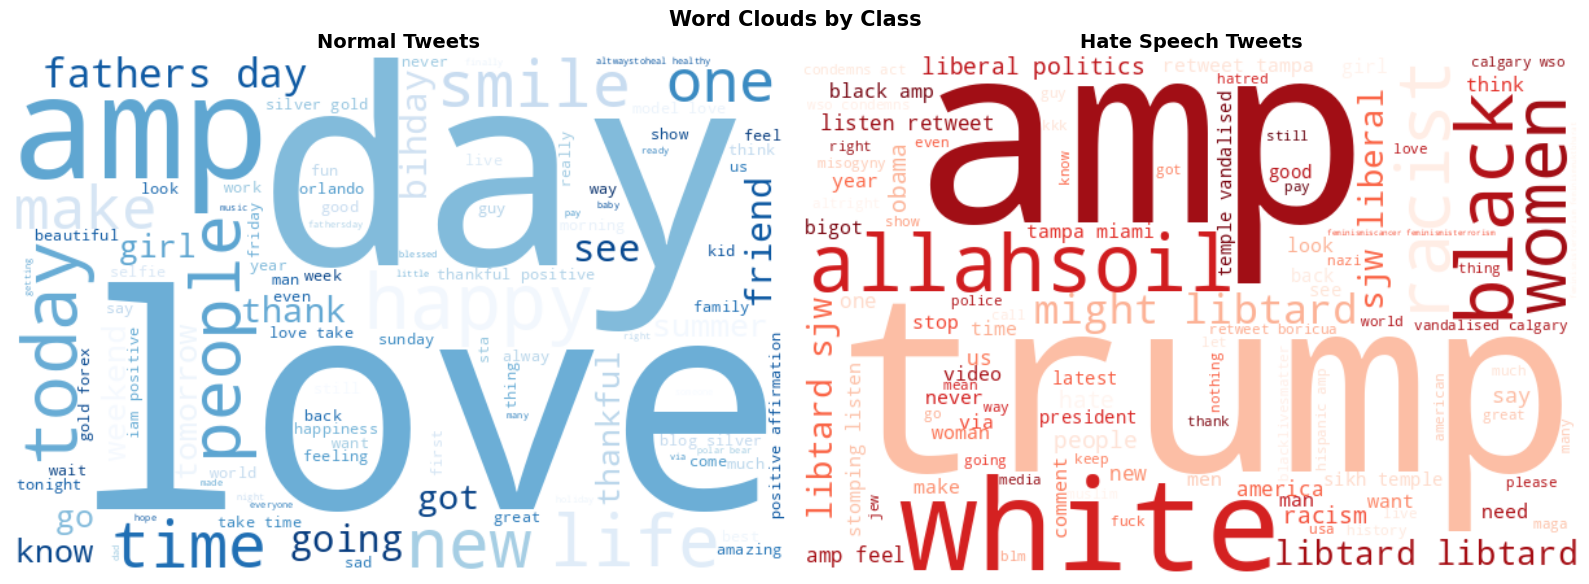

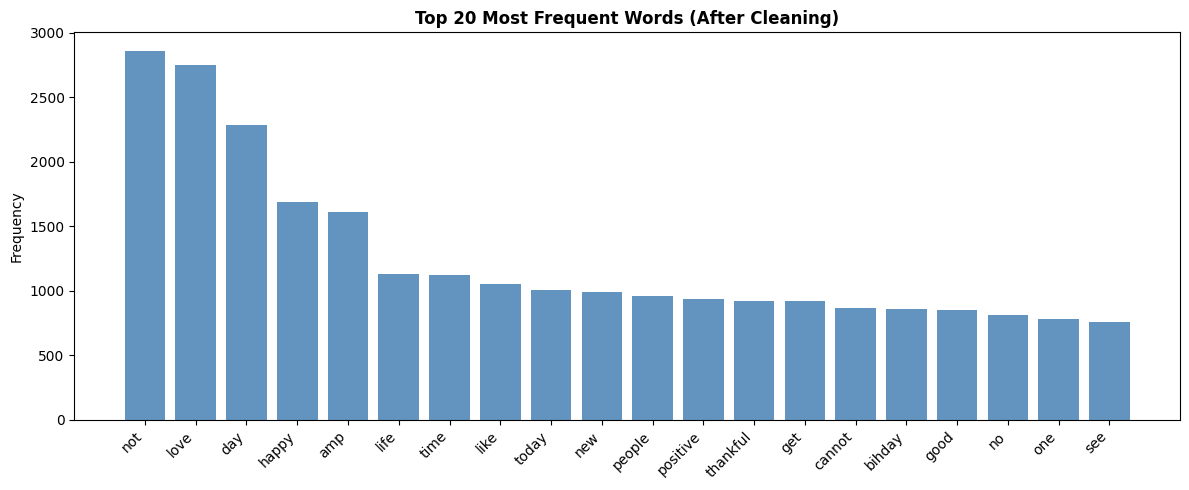

In [10]:
# Cell 6: Visualize Cleaned Data
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (label, title, color) in enumerate(zip(
        [0, 1],
        ['Normal Tweets', 'Hate Speech Tweets'],
        ['Blues', 'Reds'])):

    corpus = ' '.join(df[df['label'] == label]['cleaned'].dropna())

    # Word Cloud
    wc = WordCloud(
        width=600, height=400,
        background_color='white',
        colormap=color,
        max_words=100
    ).generate(corpus)

    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].set_title(title, fontsize=14, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle("Word Clouds by Class", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("wordclouds.png", dpi=150)
plt.show()

# Top 20 words overall
all_words = ' '.join(df['cleaned'].dropna()).split()
freq = Counter(all_words).most_common(20)
words_f, counts_f = zip(*freq)

plt.figure(figsize=(12, 5))
plt.bar(words_f, counts_f, color='steelblue', alpha=0.85)
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 Most Frequent Words (After Cleaning)', fontweight='bold')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig("top_words.png", dpi=150)
plt.show()

In [25]:
# The balanced weight will now be:
# Normal     → 29720 / (2 * 29720) = 0.5
# Hate       → 29720 / (2 * 2242)  ≈ 6.63

# So your manual weights {0: 1.0, 1: 5.0} and {0: 1.0, 1: 6.0} 
# are already well-calibrated for this dataset — no change needed
print(f"Dataset ratio: {29720/2242:.1f}:1")
print(f"Balanced weight for class 1: {29720/(2*2242):.2f}")

Dataset ratio: 13.3:1
Balanced weight for class 1: 6.63


In [11]:
# Cell 7: Train/Test Split → Tokenize → Pad
X = df['cleaned'].fillna('').values
y = df['label'].values

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

# ── Tokenizer ──
VOCAB_SIZE = 20000
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)         # fit on train only

train_seq = tokenizer.texts_to_sequences(X_train)
test_seq  = tokenizer.texts_to_sequences(X_test)

print(f"\nVocabulary size: {len(tokenizer.word_index)}")

# ── Percentile-based padding (§4.5.1) ──
lengths = [len(s) for s in train_seq]
MAX_LEN = int(np.percentile(lengths, 95))   # 95th percentile avoids extreme lengths
print(f"95th percentile sequence length → MAX_LEN = {MAX_LEN}")

X_train_pad = pad_sequences(train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"\nX_train_pad shape: {X_train_pad.shape}")
print(f"X_test_pad shape : {X_test_pad.shape}")

# Shared config
EMBED_DIM  = 128
NUM_CLASSES = len(np.unique(y))
print(f"Num classes: {NUM_CLASSES}")

Train: 25569 | Test: 6393

Vocabulary size: 34176
95th percentile sequence length → MAX_LEN = 13

X_train_pad shape: (25569, 13)
X_test_pad shape : (6393, 13)
Num classes: 2


In [30]:
model1 = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
    SimpleRNN(64),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
], name="SimpleRNN_Model")

model1.summary()


Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 3. Text Preprocessing

In [31]:
model2 = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
], name="LSTM_Model")

model2.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [32]:
# Cell 10: Load pretrained Word2Vec & build embedding matrix
print("Loading Word2Vec (word2vec-google-news-300)...")
print("This may take a few minutes on first run...")

w2v_model = gensim_api.load("word2vec-google-news-300")
W2V_DIM = 300

print(f"Word2Vec loaded. Vector size: {W2V_DIM}")

# Build embedding matrix
word_index = tokenizer.word_index
embedding_matrix = np.zeros((VOCAB_SIZE, W2V_DIM))
hits, misses = 0, 0

for word, idx in word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in w2v_model:
        embedding_matrix[idx] = w2v_model[word]
        hits += 1
    else:
        misses += 1

print(f"\nEmbedding matrix shape : {embedding_matrix.shape}")
print(f"Words found in W2V     : {hits}")
print(f"Words NOT found in W2V : {misses}")
print(f"Coverage               : {hits/(hits+misses)*100:.1f}%")

Loading Word2Vec (word2vec-google-news-300)...
This may take a few minutes on first run...
Word2Vec loaded. Vector size: 300

Embedding matrix shape : (20000, 300)
Words found in W2V     : 12050
Words NOT found in W2V : 7949
Coverage               : 60.3%


In [33]:
model3 = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=W2V_DIM,
        input_length=MAX_LEN,
        weights=[embedding_matrix],
        trainable=True
    ),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
], name="LSTM_Word2Vec_Model")
model3.summary()

Model: "LSTM_Word2Vec_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ ?                      │     6,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,000,000 (22.89 MB)

 Trainable params: 6,000,000 (22.89 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Data Visualization & Exploratory Analysis

In [34]:
from sklearn.utils.class_weight import compute_class_weight

In [35]:
# Cell 12: Compile + Train
EPOCHS = 20
BATCH  = 64

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,          # back to 3 — give more room to breathe
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        factor=0.5,
        patience=2,          # back to 2 — don't reduce LR so aggressively
        min_lr=1e-6,
        verbose=1
    )
]

class_weights_per_model = {
    'Model1_SimpleRNN' : {0: 1.0, 1: 5.0},
    'Model2_LSTM'      : {0: 1.0, 1: 6.0},
    'Model3_LSTM_W2V'  : {0: 1.0, 1: 5.0},
}

lr_per_model = {
    'Model1_SimpleRNN' : 1e-3,
    'Model2_LSTM'      : 1e-3,
    'Model3_LSTM_W2V'  : 3e-4,
}

models = {
    'Model1_SimpleRNN' : model1,
    'Model2_LSTM'      : model2,
    'Model3_LSTM_W2V'  : model3
}

histories   = {}
train_times = {}

for name, model in models.items():
    print(f"\n{'='*55}")
    print(f"  Training: {name}")
    print(f"{'='*55}")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr_per_model[name]),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    t0 = time.time()
    hist = model.fit(
        X_train_pad, y_train,
        class_weight=class_weights_per_model[name],
        epochs=EPOCHS,
        batch_size=BATCH,
        validation_split=0.15,
        callbacks=callbacks,
        verbose=1
    )
    elapsed = time.time() - t0

    histories[name]   = hist
    train_times[name] = elapsed

    best_val = max(hist.history['val_accuracy'])
    print(f"\n✅ {name} | Time: {elapsed:.1f}s | Best Val Acc: {best_val:.4f}")


  Training: Model1_SimpleRNN
Epoch 1/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8989 - loss: 0.5838 - val_accuracy: 0.9137 - val_loss: 0.2101 - learning_rate: 0.0010
Epoch 2/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9767 - loss: 0.1265 - val_accuracy: 0.9473 - val_loss: 0.1488 - learning_rate: 0.0010
Epoch 3/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9919 - loss: 0.0434 - val_accuracy: 0.9539 - val_loss: 0.1888 - learning_rate: 0.0010
Epoch 4/20
328/340 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9965 - loss: 0.0229
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9965 - loss: 0.0232 - val_accuracy: 0.9481 - val_loss: 0.1979 - learning_rate: 0.0010
Epoch 5/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9971 - loss: 0.0160 - val_accuracy: 0.9450 - val_loss: 0.2077 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model weights from t

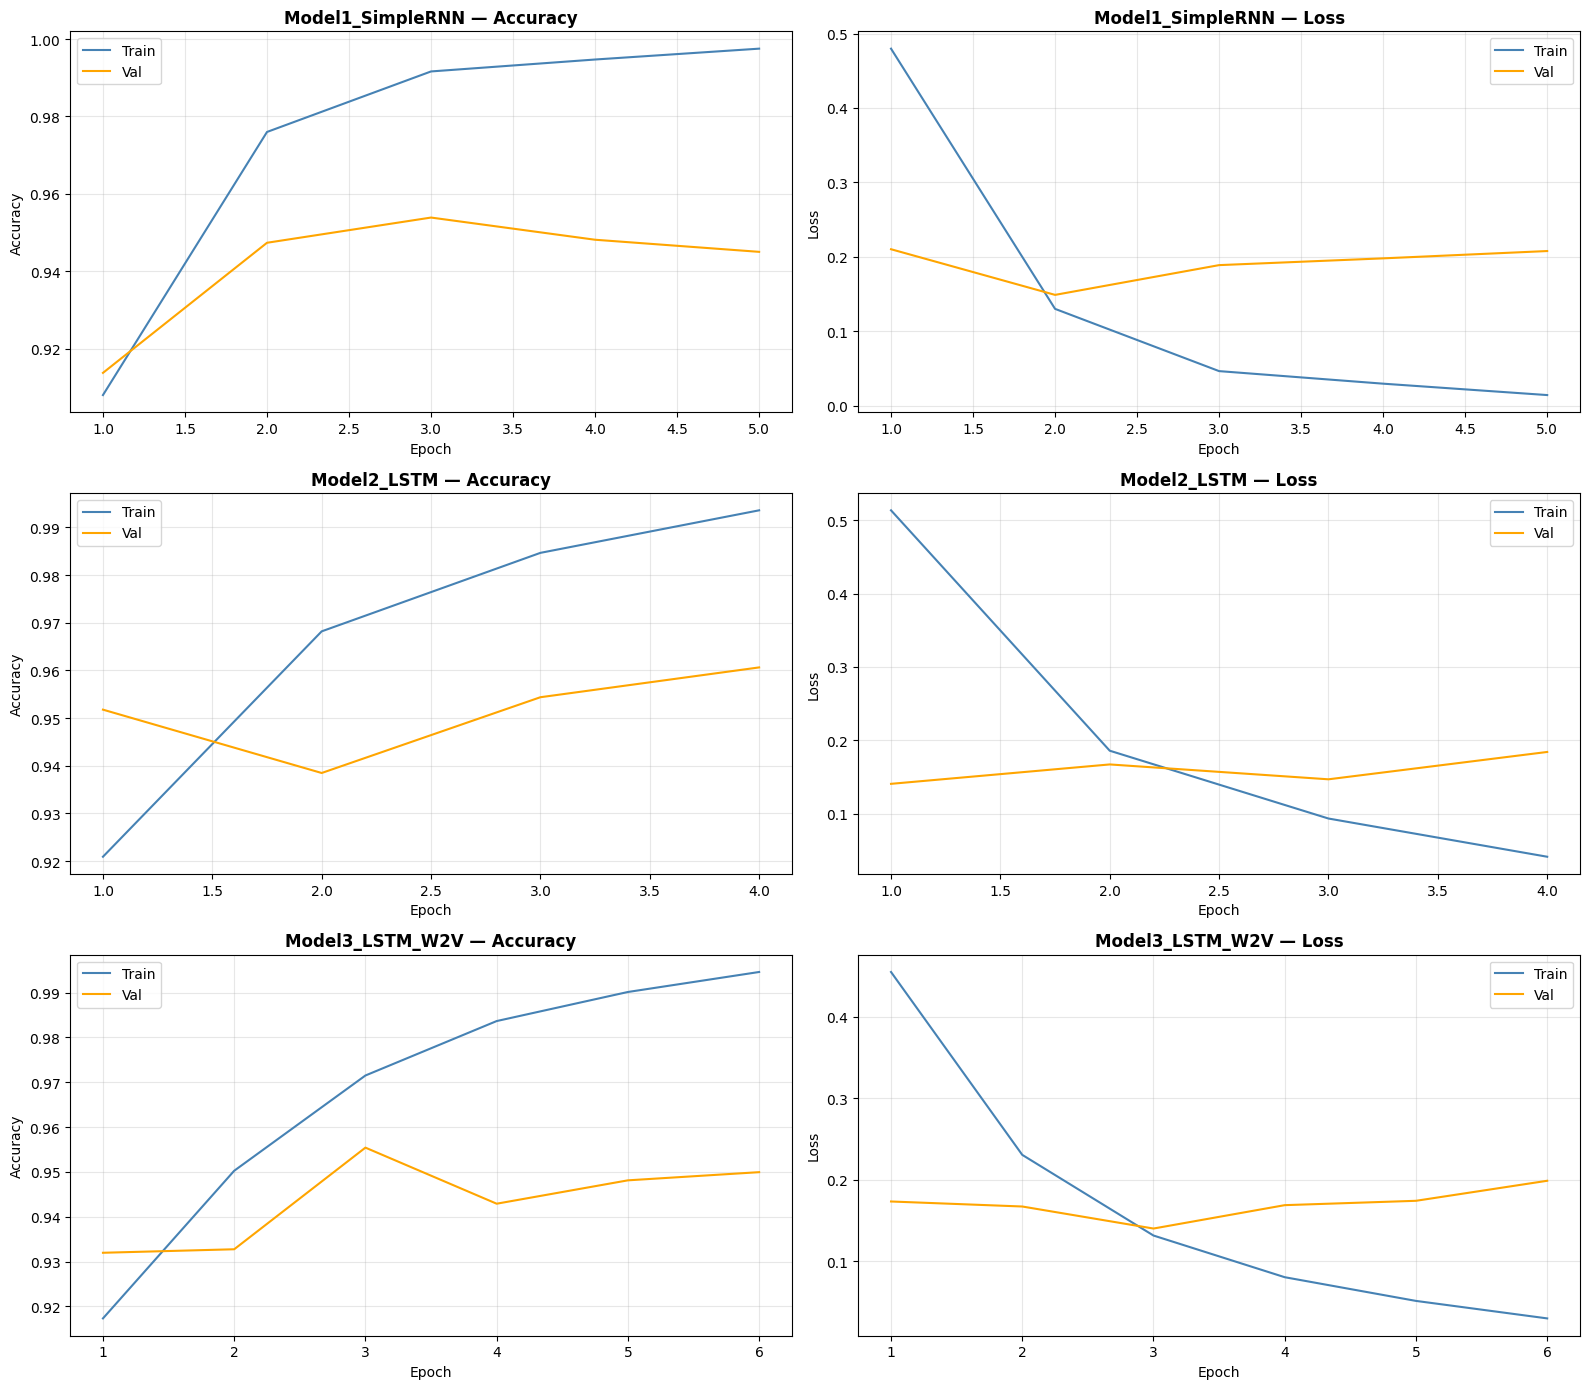

In [36]:
# Cell 13: Training vs Validation curves for all models
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

for row, (name, hist) in enumerate(histories.items()):
    acc      = hist.history['accuracy']
    val_acc  = hist.history['val_accuracy']
    loss     = hist.history['loss']
    val_loss = hist.history['val_loss']
    eps      = range(1, len(acc)+1)

    # Accuracy
    axes[row, 0].plot(eps, acc,     label='Train', color='steelblue')
    axes[row, 0].plot(eps, val_acc, label='Val',   color='orange')
    axes[row, 0].set_title(f'{name} — Accuracy', fontweight='bold')
    axes[row, 0].set_xlabel('Epoch'); axes[row, 0].set_ylabel('Accuracy')
    axes[row, 0].legend(); axes[row, 0].grid(alpha=0.3)

    # Loss
    axes[row, 1].plot(eps, loss,     label='Train', color='steelblue')
    axes[row, 1].plot(eps, val_loss, label='Val',   color='orange')
    axes[row, 1].set_title(f'{name} — Loss', fontweight='bold')
    axes[row, 1].set_xlabel('Epoch'); axes[row, 1].set_ylabel('Loss')
    axes[row, 1].legend(); axes[row, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

## 5. Tokenization, Train/Test Split & Sequence Padding


  Model1_SimpleRNN
              precision    recall  f1-score   support

      Normal       0.98      0.97      0.97      5945
 Hate Speech       0.61      0.68      0.64       448

    accuracy                           0.95      6393
   macro avg       0.79      0.82      0.81      6393
weighted avg       0.95      0.95      0.95      6393


  Model2_LSTM
              precision    recall  f1-score   support

      Normal       0.98      0.97      0.97      5945
 Hate Speech       0.62      0.69      0.65       448

    accuracy                           0.95      6393
   macro avg       0.80      0.83      0.81      6393
weighted avg       0.95      0.95      0.95      6393


  Model3_LSTM_W2V
              precision    recall  f1-score   support

      Normal       0.98      0.97      0.97      5945
 Hate Speech       0.63      0.69      0.66       448

    accuracy                           0.95      6393
   macro avg       0.80      0.83      0.82      6393
weighted avg       0

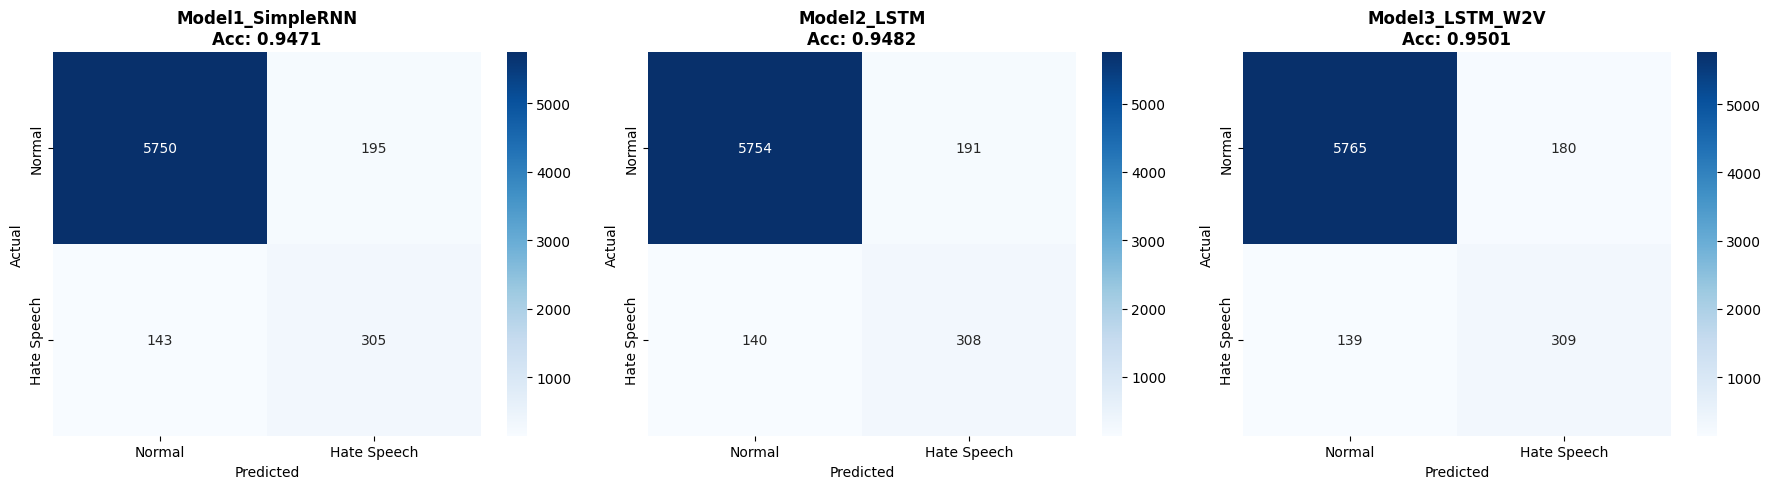

In [37]:
# Cell 14: Full Evaluation of all 3 models
results = {}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
CLASS_NAMES = ['Normal', 'Hate Speech']

for col, (name, model) in enumerate(models.items()):
    y_pred_prob = model.predict(X_test_pad, verbose=0).flatten()
    y_pred      = (y_pred_prob >= 0.5).astype(int)

    acc  = accuracy_score(y_test, y_pred)
    cm   = confusion_matrix(y_test, y_pred)
    rep  = classification_report(y_test, y_pred, target_names=CLASS_NAMES, output_dict=True)

    results[name] = {
        'accuracy'  : acc,
        'precision' : rep['weighted avg']['precision'],
        'recall'    : rep['weighted avg']['recall'],
        'f1'        : rep['weighted avg']['f1-score'],
        'train_time': train_times[name]
    }

    # Confusion matrix plot
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        ax=axes[col]
    )
    axes[col].set_title(f'{name}\nAcc: {acc:.4f}', fontweight='bold')
    axes[col].set_xlabel('Predicted')
    axes[col].set_ylabel('Actual')

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()

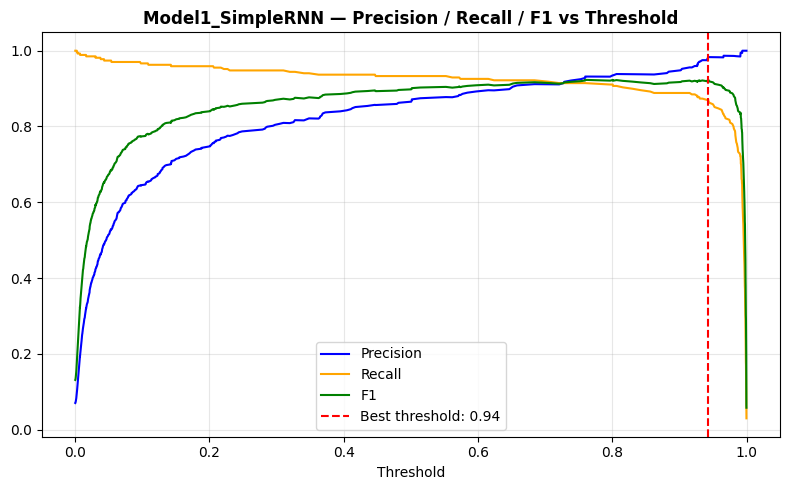

Model1_SimpleRNN → Best threshold: 0.943  | F1: 0.9231  | P: 0.9832  | R: 0.8699


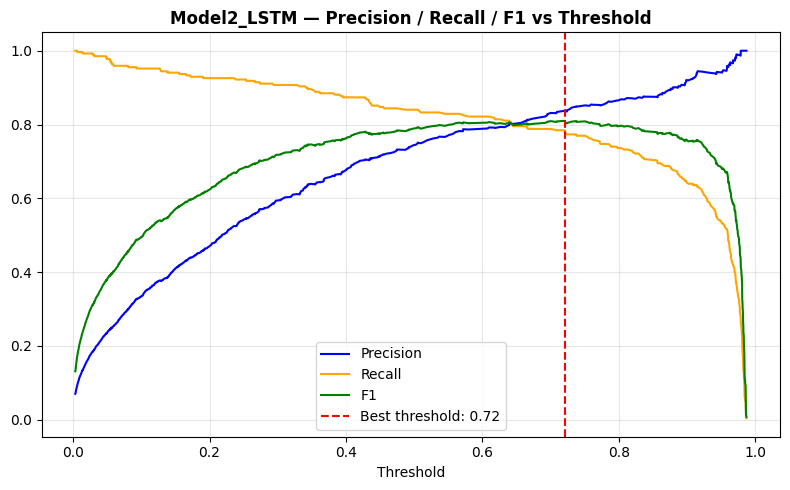

Model2_LSTM → Best threshold: 0.721  | F1: 0.8100  | P: 0.8373  | R: 0.7844


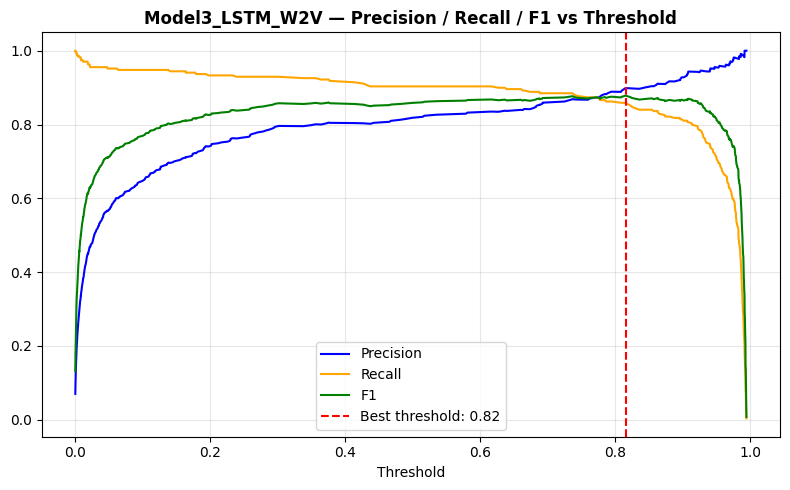

Model3_LSTM_W2V → Best threshold: 0.815  | F1: 0.8783  | P: 0.8988  | R: 0.8587

Optimal thresholds: {'Model1_SimpleRNN': np.float32(0.94282997), 'Model2_LSTM': np.float32(0.7207232), 'Model3_LSTM_W2V': np.float32(0.81525177)}


In [38]:
# Cell: Find optimal threshold per model
from sklearn.metrics import f1_score, precision_recall_curve

def find_best_threshold(model, X_val, y_val, model_name):
    y_prob = model.predict(X_val, verbose=0).flatten()
    
    precisions, recalls, thresholds = precision_recall_curve(y_val, y_prob)
    
    # F1 at each threshold
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_idx   = np.argmax(f1_scores)
    best_thresh = thresholds[best_idx]
    best_f1     = f1_scores[best_idx]
    
    # Plot precision-recall curve
    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, precisions[:-1], label='Precision', color='blue')
    plt.plot(thresholds, recalls[:-1],    label='Recall',    color='orange')
    plt.plot(thresholds, f1_scores[:-1],  label='F1',        color='green')
    plt.axvline(best_thresh, color='red', linestyle='--',
                label=f'Best threshold: {best_thresh:.2f}')
    plt.xlabel('Threshold')
    plt.title(f'{model_name} — Precision / Recall / F1 vs Threshold',
              fontweight='bold')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"{model_name} → Best threshold: {best_thresh:.3f}  "
          f"| F1: {best_f1:.4f}  | P: {precisions[best_idx]:.4f}  "
          f"| R: {recalls[best_idx]:.4f}")
    return best_thresh

# You need a validation split for this — create one from test set
# or use the val split from training
X_tr2, X_val2, y_tr2, y_val2 = train_test_split(
    X_train_pad, y_train, test_size=0.15, random_state=42, stratify=y_train
)

thresholds_dict = {}
for name, model in models.items():
    t = find_best_threshold(model, X_val2, y_val2, name)
    thresholds_dict[name] = t

print("\nOptimal thresholds:", thresholds_dict)

In [39]:
# Re-evaluate with optimal thresholds
for col, (name, model) in enumerate(models.items()):
    thresh = thresholds_dict[name]
    y_prob = model.predict(X_test_pad, verbose=0).flatten()
    y_pred = (y_prob >= thresh).astype(int)
    
    print(f"\n{'='*50}")
    print(f"  {name}  (threshold={thresh:.3f})")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred,
                                 target_names=CLASS_NAMES))


  Model1_SimpleRNN  (threshold=0.943)
              precision    recall  f1-score   support

      Normal       0.96      0.99      0.98      5945
 Hate Speech       0.86      0.51      0.64       448

    accuracy                           0.96      6393
   macro avg       0.91      0.75      0.81      6393
weighted avg       0.96      0.96      0.96      6393


  Model2_LSTM  (threshold=0.721)
              precision    recall  f1-score   support

      Normal       0.97      0.98      0.98      5945
 Hate Speech       0.73      0.61      0.67       448

    accuracy                           0.96      6393
   macro avg       0.85      0.80      0.82      6393
weighted avg       0.95      0.96      0.96      6393


  Model3_LSTM_W2V  (threshold=0.815)
              precision    recall  f1-score   support

      Normal       0.97      0.99      0.98      5945
 Hate Speech       0.78      0.62      0.69       448

    accuracy                           0.96      6393
   macro avg     

                  accuracy  precision  recall      f1  train_time_min
Model1_SimpleRNN    0.9471     0.9501  0.9471  0.9485          0.2296
Model2_LSTM         0.9482     0.9511  0.9482  0.9495          0.2479
Model3_LSTM_W2V     0.9501     0.9523  0.9501  0.9511          0.4066


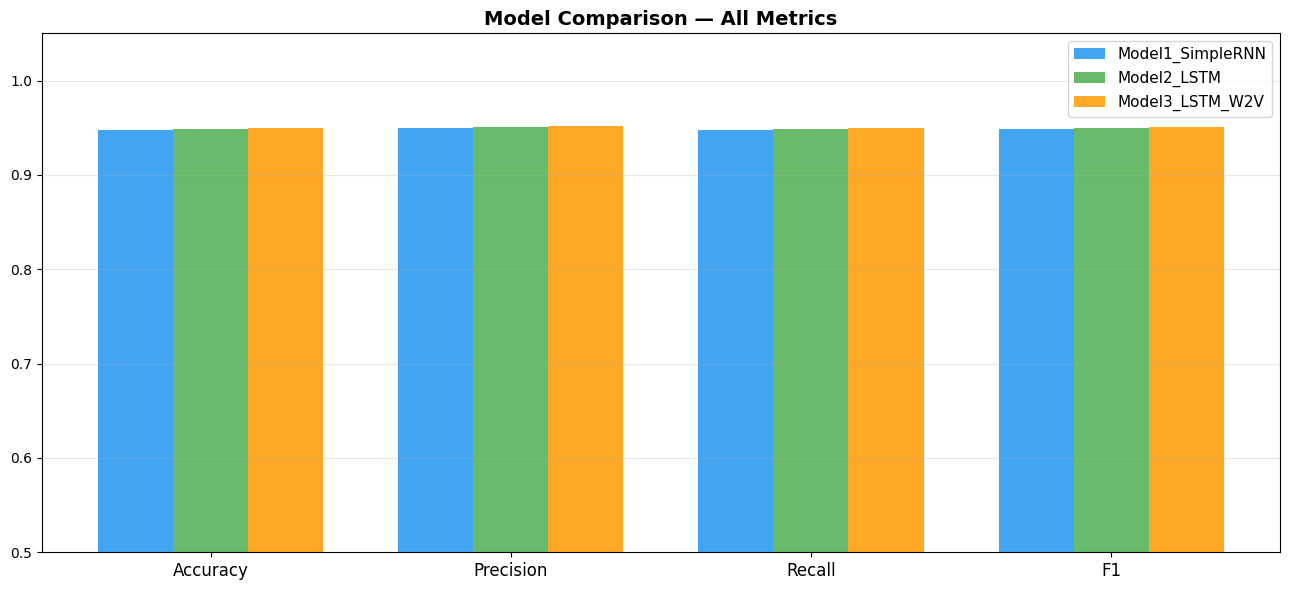

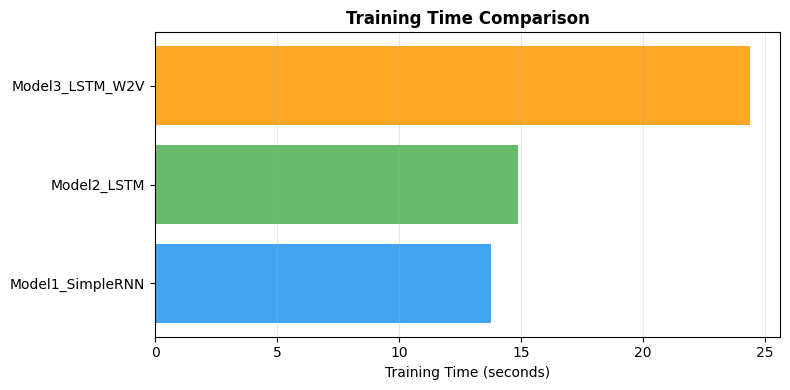

In [40]:
# Cell 15: Side-by-side model comparison
results_df = pd.DataFrame(results).T
results_df['train_time_min'] = results_df['train_time'] / 60
print(results_df[['accuracy','precision','recall','f1','train_time_min']].round(4))

# Bar chart comparison
metrics = ['accuracy', 'precision', 'recall', 'f1']
x  = np.arange(len(metrics))
w  = 0.25
colors = ['#2196F3', '#4CAF50', '#FF9800']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (name, row) in enumerate(results_df.iterrows()):
    vals = [row[m] for m in metrics]
    ax.bar(x + i*w, vals, w, label=name, color=colors[i], alpha=0.85)

ax.set_xticks(x + w)
ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1'], fontsize=12)
ax.set_ylim(0.5, 1.05)
ax.set_title('Model Comparison — All Metrics', fontweight='bold', fontsize=14)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()

# Training time
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(list(results_df.index), results_df['train_time'], color=colors, alpha=0.85)
ax.set_xlabel('Training Time (seconds)')
ax.set_title('Training Time Comparison', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig("train_times.png", dpi=150)
plt.show()

In [41]:
# Cell 16: Error Analysis — use best model (Model 3)
best_model = model3   # swap to whichever performed best

y_pred_prob = best_model.predict(X_test_pad, verbose=0).flatten()
y_pred_best = (y_pred_prob >= 0.5).astype(int)

# Find misclassified indices
errors = np.where(y_pred_best != y_test)[0]
print(f"Total misclassifications: {len(errors)} / {len(y_test)} "
      f"({len(errors)/len(y_test)*100:.1f}%)\n")

# Show 5 examples
print("=" * 70)
print("  MISCLASSIFIED EXAMPLES")
print("=" * 70)

for i, idx in enumerate(errors[:5]):
    raw_tweet  = X_test[idx]
    true_label = CLASS_NAMES[y_test[idx]]
    pred_label = CLASS_NAMES[y_pred_best[idx]]
    confidence = y_pred_prob[idx] if y_pred_best[idx] == 1 else 1 - y_pred_prob[idx]

    print(f"\nExample {i+1}:")
    print(f"  Tweet     : {raw_tweet[:120]}...")
    print(f"  True Label: {true_label}")
    print(f"  Predicted : {pred_label}  (confidence: {confidence:.2f})")
    print(f"  {'⚠️  False Positive' if y_test[idx]==0 else '⚠️  False Negative'}")


Total misclassifications: 319 / 6393 (5.0%)

  MISCLASSIFIED EXAMPLES

Example 1:
  Tweet     : goofy idiot lot goofy dumb americans get nod goofydonnie...
  True Label: Normal
  Predicted : Hate Speech  (confidence: 0.81)
  ⚠️  False Positive

Example 2:
  Tweet     : immature trying make fool xenophobe immature moron...
  True Label: Hate Speech
  Predicted : Normal  (confidence: 0.95)
  ⚠️  False Negative

Example 3:
  Tweet     : yapping right idiot trump...
  True Label: Normal
  Predicted : Hate Speech  (confidence: 0.89)
  ⚠️  False Positive

Example 4:
  Tweet     : president woodrowwilson held private screening dw griffiths bih nation history th...
  True Label: Hate Speech
  Predicted : Normal  (confidence: 0.99)
  ⚠️  False Negative

Example 5:
  Tweet     : gf used uber without forcing language preferences reading data making ux choices...
  True Label: Hate Speech
  Predicted : Normal  (confidence: 1.00)
  ⚠️  False Negative


True  Positives (Hate correctly detected)  : 309
True  Negatives (Normal correctly detected) : 5765
False Positives (Normal → flagged as Hate)  : 180
False Negatives (Hate → missed as Normal)   : 139

False Positive Rate : 0.0303
False Negative Rate : 0.3103


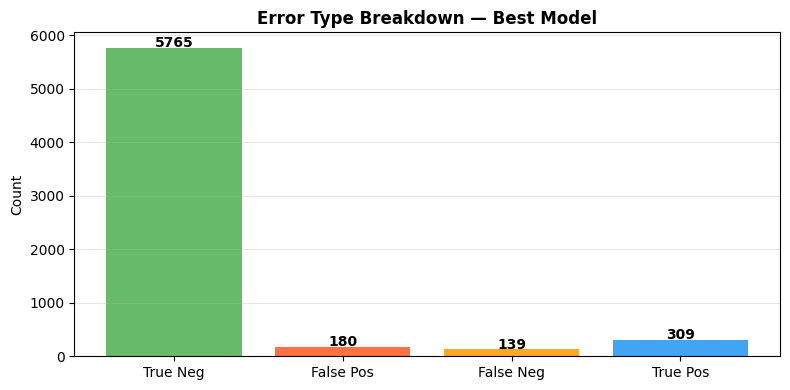

In [42]:
# Cell 17: False Positive / False Negative Breakdown
cm_best = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm_best.ravel()

print(f"True  Positives (Hate correctly detected)  : {tp}")
print(f"True  Negatives (Normal correctly detected) : {tn}")
print(f"False Positives (Normal → flagged as Hate)  : {fp}")
print(f"False Negatives (Hate → missed as Normal)   : {fn}")
print(f"\nFalse Positive Rate : {fp/(fp+tn):.4f}")
print(f"False Negative Rate : {fn/(fn+tp):.4f}")

labels_cm = ['True Neg', 'False Pos', 'False Neg', 'True Pos']
vals_cm   = [tn, fp, fn, tp]
colors_cm = ['#4CAF50', '#FF5722', '#FF9800', '#2196F3']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels_cm, vals_cm, color=colors_cm, alpha=0.85)
for bar, val in zip(bars, vals_cm):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', fontweight='bold')
ax.set_title('Error Type Breakdown — Best Model', fontweight='bold')
ax.set_ylabel('Count')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("error_analysis.png", dpi=150)
plt.show()

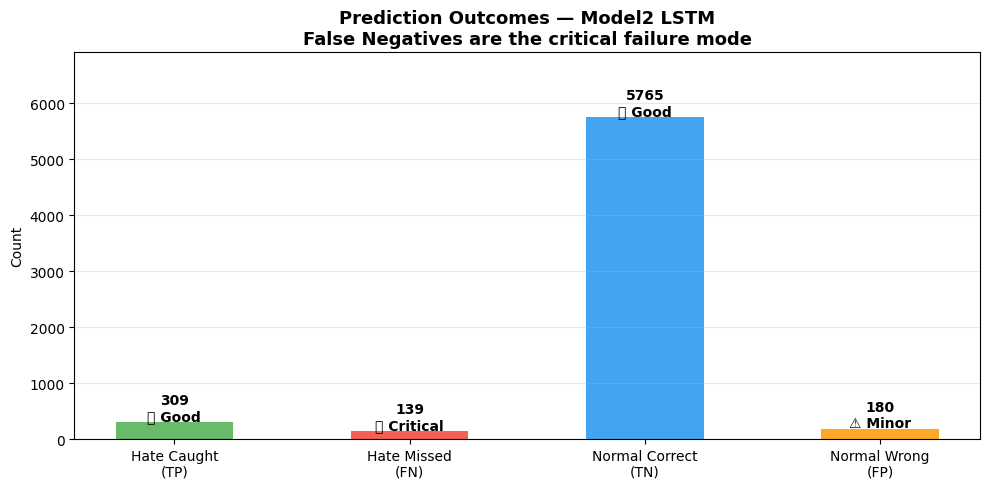

In [43]:
# Cost-weighted error visualisation
categories = ['Hate Caught\n(TP)', 'Hate Missed\n(FN)', 
              'Normal Correct\n(TN)', 'Normal Wrong\n(FP)']
values  = [309, 139, 5765, 180]
colors  = ['#4CAF50', '#F44336', '#2196F3', '#FF9800']
impacts = ['✅ Good', '❌ Critical', '✅ Good', '⚠️ Minor']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(categories, values, color=colors, alpha=0.85, width=0.5)

for bar, val, imp in zip(bars, values, impacts):
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 30,
            f'{val}\n{imp}', 
            ha='center', fontweight='bold', fontsize=10)

ax.set_title('Prediction Outcomes — Model2 LSTM\n'
             'False Negatives are the critical failure mode',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Count')
ax.set_ylim(0, max(values) * 1.2)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("error_breakdown.png", dpi=150)
plt.show()

In [44]:
# Cell 18: Real-Time Prediction GUI with Gradio (Updated)
import gradio as gr

# Tuned thresholds from validation
THRESHOLDS = {
    'SimpleRNN' : thresholds_dict['Model1_SimpleRNN'],
    'LSTM'      : thresholds_dict['Model2_LSTM'],
    'LSTM+W2V'  : thresholds_dict['Model3_LSTM_W2V'],
}

def predict_tweet(tweet_text):
    if not tweet_text.strip():
        return "⚠️ Please enter a tweet.", ""

    # Use updated cleaner (v2)
    cleaned = clean_tweet(tweet_text)

    if not cleaned.strip():
        return "⚠️ Nothing meaningful left after cleaning.", ""

    # Tokenize & pad
    seq    = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

    # Predict with all 3 models using tuned thresholds
    probs = {
        'SimpleRNN' : model1.predict(padded, verbose=0)[0][0],
        'LSTM'      : model2.predict(padded, verbose=0)[0][0],
        'LSTM+W2V'  : model3.predict(padded, verbose=0)[0][0],
    }

    def fmt(name, prob):
        thresh = THRESHOLDS[name]
        is_hate = prob >= thresh
        label   = "🚨 Hate Speech" if is_hate else "✅ Normal"
        conf    = prob if is_hate else 1 - prob
        return f"{name:<12} | {label:<20} | Confidence: {conf*100:.1f}%  (threshold: {thresh:.2f})"

    lines = [
        "─" * 62,
        fmt('SimpleRNN',  probs['SimpleRNN']),
        fmt('LSTM',       probs['LSTM']),
        fmt('LSTM+W2V',   probs['LSTM+W2V']),
        "─" * 62,
    ]

    # Majority vote using tuned thresholds
    votes     = sum(1 for name, prob in probs.items() if prob >= THRESHOLDS[name])
    consensus = "🚨 Hate Speech" if votes >= 2 else "✅ Normal"
    lines.append(f"Majority Vote ({votes}/3 models): {consensus}")

    result          = "\n".join(lines)
    cleaned_display = f"Cleaned: '{cleaned}'"

    return result, cleaned_display


# Build Gradio UI
with gr.Blocks(theme=gr.themes.Soft(), title="Tweet Hate Speech Detector") as demo:
    gr.Markdown("# 🐦 Tweet Hate Speech Classifier")
    gr.Markdown(
        "Enter a tweet below. All three models classify it using **tuned thresholds** "
        "optimised for hate speech detection. A majority vote gives the final verdict."
    )

    with gr.Row():
        with gr.Column(scale=1):
            tweet_input = gr.Textbox(
                label="Enter Tweet",
                placeholder="Type your tweet here...",
                lines=3
            )
            btn = gr.Button("🔍 Classify", variant="primary")

            gr.Markdown(
                f"**Tuned Thresholds:** "
                f"SimpleRNN={THRESHOLDS['SimpleRNN']:.2f} | "
                f"LSTM={THRESHOLDS['LSTM']:.2f} | "
                f"LSTM+W2V={THRESHOLDS['LSTM+W2V']:.2f}"
            )

        with gr.Column(scale=1):
            output_pred    = gr.Textbox(label="Model Predictions + Majority Vote", lines=8)
            output_cleaned = gr.Textbox(label="Preprocessed Text", lines=2)

    btn.click(
        fn=predict_tweet,
        inputs=tweet_input,
        outputs=[output_pred, output_cleaned]
    )

    gr.Examples(
        examples=[
            ["I hate all those people, they should be banned forever"],
            ["Just had the best coffee of my life, great day!"],
            ["Women can't drive and shouldn't be allowed in the workplace"],
            ["go back to your own country you don't belong here"],
            ["Had a wonderful time at the park with friends today!"],
        ],
        inputs=tweet_input
    )

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://cb0c10ef93c8de80b5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [45]:
# Cell 19: Final Summary
print("=" * 65)
print("          FULL EXPERIMENT SUMMARY")
print("=" * 65)
print(f"{'Model':<25} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7} {'Time(s)':>9}")
print("-" * 65)
for name, r in results.items():
    short = name.replace('Model1_','').replace('Model2_','').replace('Model3_','')
    print(f"{short:<25} {r['accuracy']:>7.4f} {r['precision']:>7.4f} "
          f"{r['recall']:>7.4f} {r['f1']:>7.4f} {r['train_time']:>9.1f}s")


          FULL EXPERIMENT SUMMARY
Model                         Acc    Prec     Rec      F1   Time(s)
-----------------------------------------------------------------
SimpleRNN                  0.9471  0.9501  0.9471  0.9485      13.8s
LSTM                       0.9482  0.9511  0.9482  0.9495      14.9s
LSTM_W2V                   0.9501  0.9523  0.9501  0.9511      24.4s
